<a href="https://colab.research.google.com/github/Abhinaytechie/LangGraph/blob/main/Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain langchain_groq langchain_community langgraph

In [ ]:
from google.colab import userdata
from langchain_groq import ChatGroq

api_key = userdata.get('GROQ_API_KEY')
llm = ChatGroq(model="openai/gpt-oss-120b",groq_api_key=api_key,verbose=True)


In [ ]:
import http.client,json

def jobsearch(skill: str, location: str):
    """
    using the jsearch api search latest jobs
    """

    conn = http.client.HTTPSConnection("jsearch.p.rapidapi.com")
    headers = {
        'x-rapidapi-key': "716e0079aamsh6d5467dd0387abdp15887bjsn8b95211720ae",
        'x-rapidapi-host': "jsearch.p.rapidapi.com"
    }

    conn.request(
        "GET",
        f"/search?query={skill}%20jobs%20in%20{location}&page=1&num_pages=1&country=in&date_posted=all",
        headers=headers
    )
    res = conn.getresponse()
    data = res.read().decode("utf-8")
    conn.close()

    jobs = json.loads(data).get("data", [])

    if not jobs:
        return "⚠️ No jobs found."

    # 🧾 Neat formatting
    output = "\n🔹 **Job Listings** 🔹\n\n"
    for i, job in enumerate(jobs[:5], start=1):  # Limit to 5 jobs
        title = job.get("job_title", "N/A")
        companies = job.get("employer_name", "N/A")
        city = job.get("job_city", "N/A")
        link = job.get("job_apply_link", "N/A")
        desc = job.get("job_description", "No description provided.")[:250].replace("\n", " ") + "..."

        output += (
            f"🧠 **{i}. {title}**\n"
            f"🏢 Company: {companies}\n"
            f"📍 Location: {city}\n"
            f"🔗 Apply: {link}\n"
            f"📝 Description: {desc}\n"
            "----------------------------------------\n\n"
        )
    return output



In [ ]:
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain
from langchain.llms import OpenAI
google_serper=GoogleSerperAPIWrapper(serper_api_key=userdata.get('SERPER_API_KEY'))

In [ ]:
# google_serper.results("Get the hr email of ENdpoint Clincal")['organic']

In [ ]:
def get_company_profiles(**kwargs):
    """
    to get hr emails
    """
    companies = kwargs.get("companies", [])
    if isinstance(companies, list):
        companies_str = ", ".join(companies)
    else:
        companies_str = str(companies)

    query = f"""
You are a professional job research assistant. Your task is to gather meaningful and actionable insights about the following companies.
Do not focus on personal emails or private contacts. Instead, include publicly available information that helps job seekers understand each company better.

For each company, provide information in JSON format with the following fields:
    • Company name
    • Company overview / description
    • Key projects, products, or services
    • Technologies, tools, and skills commonly used
    • Interview process (stages, types of interviews, common questions)
    • Work culture, values, or notable employee benefits
    • Careers page URL or job portal link
    • LinkedIn/company profile link (if publicly available)

Companies: {companies_str}

Return the output strictly in **JSON format**, with each company as a separate object.
Be concise, clear, and accurate.
"""
    results_text = google_serper.results(query)
    return results_text['organic']


In [ ]:
tools=[jobsearch,get_company_profiles]
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

In [ ]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message

sys_msg = SystemMessage(
    content="""
You are a professional job search and company research assistant. You have two tools:

1. jobsearch: Finds the latest jobs for a given role, skills, and location.
2. get_company_insights: Provides detailed, actionable insights about specific companies.

Important rules:
- Take skills in the qyery an append them without space using "+"
- Only call get_company_insights if the user explicitly asks for company insights, such as interview process, projects, technologies used, or work culture.
- Otherwise, only call jobsearch and return its output as-is, without modifying JSON.

- When retrieving company insights, include for each company:
    • Company name
    • Company overview / description
    • Key projects, products, or services
    • Technologies, tools, and skills commonly used
    • Interview process (stages, types of interviews, common questions)
    • Work culture, values, or notable employee benefits
    • Careers page URL or job portal link
    • LinkedIn/company profile link (if publicly available)
- Do not include personal emails or private contacts.
- Prefer publicly available sources.
- Return all outputs in **JSON format** for easy processing.

Always be concise, accurate, ethical, and helpful.
"""
)


# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [ ]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")


# Show


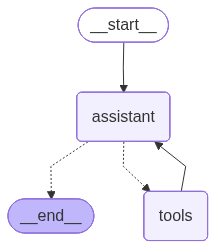

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
react_graph_memory=builder.compile(checkpointer=memory)
display(Image(react_graph_memory.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
state=react_graph_memory.get_state(config)
state.next

NameError: name 'config' is not defined

In [ ]:
config={"configurable":{"thread_id": "2"}}
messages = [HumanMessage(content="I just want latest AIDevloper Jobs in Hyderbad ")]
messages = react_graph_memory.invoke({"messages": messages},config=config)
for m in messages['messages']:
    m.pretty_print()

In [ ]:
messages = [HumanMessage(content="give a brief about the companies")]
for event in react_graph_memory.stream({"messages":messages},config,stream_mode='values'):
  event['messages'][-1].pretty_print()


In [ ]:
for event in react_graph_memory.stream({"messages":messages},config,stream_mode='values'):
  event['messages'][-1].pretty_print()

In [ ]:
thread={"configurable":{"thread_id":"6"}}

In [ ]:
messages = [HumanMessage(content="I just want latest AIDevloper Jobs in Hyderbad")]
for event in react_graph_memory.stream({"messages":messages},thread,stream_mode='values'):
  event['messages'][-1].pretty_print()


================================ Human Message =================================

I just want latest AIDevloper Jobs in Hyderbad
================================== Ai Message ==================================
Tool Calls:
  jobsearch (fc_02f19e71-8efa-4513-bbbd-72e0382cf7b1)
 Call ID: fc_02f19e71-8efa-4513-bbbd-72e0382cf7b1
  Args:
    location: Hyderabad
    skill: AIDevloper
================================= Tool Message =================================
Name: jobsearch


🔹 **Job Listings** 🔹

🧠 **1. Lead AEM UI Developer**
🏢 Company: Xerago
📍 Location: Hyderabad
🔗 Apply: https://www.shine.com/jobs/lead-aem-ui-developer/xerago/17997190?utm_campaign=google_jobs_apply&utm_source=google_jobs_apply&utm_medium=organic
📝 Description: As an experienced AEM UI Lead Developer at our company, you will play a crucial role in guiding the front-end development team and ensuring the delivery of high-quality web solutions on the AEM Cloud. Your expertise in Adobe Experience Manager as a C...
------

In [ ]:
react_graph_memory.get_state(thread)

In [ ]:
states=[s for s in react_graph_memory.get_state_history(thread)]

In [ ]:
len(states)

In [ ]:
fork_config=states[-2]
fork=fork_config.config
to_replay=states[-2].values['messages']
print(to_replay)

[HumanMessage(content='I just want latest AIDevloper Jobs in Hyderbad', additional_kwargs={}, response_metadata={}, id='c9d663da-1870-4ddd-977b-d9b8c8a0760e')]


In [ ]:
fork

In [ ]:
for event in react_graph_memory.stream(None,fork,stream_mode='values'):
  event['messages'][-1].pretty_print()

================================ Human Message =================================

I just want latest AIDevloper Jobs in Hyderbad
================================== Ai Message ==================================
Tool Calls:
  jobsearch (fc_a00a0bb6-f105-40f7-833c-9c0828ff0dec)
 Call ID: fc_a00a0bb6-f105-40f7-833c-9c0828ff0dec
  Args:
    location: Hyderabad
    skill: AIDevloper
================================= Tool Message =================================
Name: jobsearch


🔹 **Job Listings** 🔹

🧠 **1. Lead AEM UI Developer**
🏢 Company: Xerago
📍 Location: Hyderabad
🔗 Apply: https://www.shine.com/jobs/lead-aem-ui-developer/xerago/17997190?utm_campaign=google_jobs_apply&utm_source=google_jobs_apply&utm_medium=organic
📝 Description: As an experienced AEM UI Lead Developer at our company, you will play a crucial role in guiding the front-end development team and ensuring the delivery of high-quality web solutions on the AEM Cloud. Your expertise in Adobe Experience Manager as a C...
------

In [ ]:
msg=[HumanMessage(content="I want data analyst internships in hyderabad",id=to_replay[0].id)]
config_fork=react_graph_memory.update_state(fork,{"messages":msg})

In [ ]:
states=[s for s in react_graph_memory.get_state_history(thread)]
states[0].values['messages']

In [ ]:
for event in react_graph_memory.stream(None,config_fork,stream_mode='values'):
  event['messages'][-1].pretty_print()

In [ ]:
for event in react_graph_memory.stream(None,config_fork,stream_mode='values'):
  event['messages'][-1].pretty_print()